# **Assignment 8**
This exercise has two parts:

- Part A consists of mandatory exercises; you need to complete these and hand in your answers to be able to partake in the exam. This part also provides you with an impression of the minimum knowledge level necessary to pass the exam.
- Part B consists of additional exercises. These repeat a concept that is covered in Part A or help to broaden or deepen your understanding of some of the topics.  In Part B of this particular assignment, for instance, some scikit-learn functionality that could come in handy for the project is introduced.

## Assignment by
Lan Stare, s1169977

Aaron Ritz, s1170346

# **Part A** - Mandatory Exercises
Below you will find the mandatory exercises for Week 8 of the course Data Mining and Machine Learning.

# **Exercise 1** - Overfitting for Polynomial Regression

We're going to consider some simple 1D problem and see how least squares regression, where we fit polynomials of increasing degree, performs for different training sample sizes.

The particular input we use is uniform on [-5,5].  The output is generated as follows: take the input value and add its absolute value to it.  Finally, add standard uniform [0,1] noise to the value obtained.  The code below is a basic example that should generate such data.

In [1]:
import numpy as np

# init
N = 1000  # number of data points to generate
X_range = [-5.0, 5.0]  # range for the input variable
noise_range = [0.0, 1.0]  # noise range

# generate input
X = np.random.uniform(X_range[0], X_range[1], N)

# generate output
noise = np.random.uniform(noise_range[0], noise_range[1], N)
Y = (np.abs(X) + X) + noise

print(X, Y)

[-2.16839791 -1.79432706  4.50213968  4.79426454 -3.40884275 -1.1811712
 -0.94529999  4.63343634 -3.95310384  2.11994395 -1.03938984  2.03404025
 -1.67207349  1.06228409  0.42901847  1.65381641 -2.59497417  1.54274515
 -2.47446818  0.31362486 -0.31486051 -2.18889904  2.76717034  2.84646887
  1.73575576 -4.97513519  0.16441236  3.80312096  2.34243231  2.71443709
  1.13998097  2.54164735 -2.60526034 -4.2573088   0.8615579  -4.03296405
  0.04090345 -4.76887017 -0.42492064  3.04012501  2.60777391  0.10494056
  2.79064452  3.92675478 -2.38827349 -3.76632462  4.47767564  2.95670426
 -4.42359755 -2.43947235  3.63346449  2.68971787  3.37694414 -2.7994504
 -0.37431184  2.71220978  1.15219928 -3.25258537  1.09041673  4.27470896
 -1.33894343  4.57342553  0.46810357 -1.85300406  0.20087103 -2.34358859
  3.62805662  3.03948571 -1.04570394  0.858209   -0.48833822  4.72623977
  2.63335855  4.12079864 -3.14168593 -0.5857375   3.95706846 -2.82873822
 -1.97881519 -4.64566326  1.73087908  3.80266951 -0.8

**a.** Visualize 1,000 examples of input-output data.

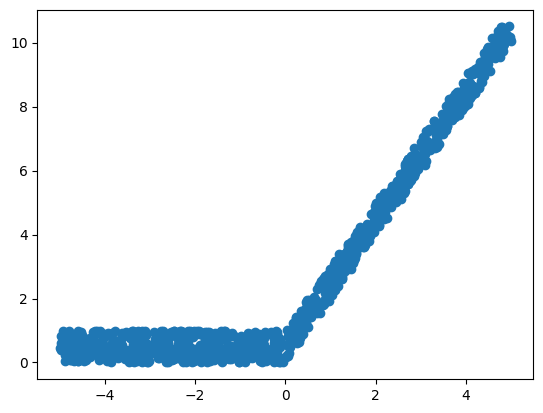

In [2]:
import matplotlib.pyplot as plt
import math

plt.figure()
plt.scatter(X, Y)
plt.show()

**b.** Linear least-squares regression is implemented through sci-kit-learn's ```sklearn.linear_model.LinearRegression```, while polynomial expansions of some inital input data, can be generated through ```sklearn.preprocessing.PolynomialFeatures``` (maybe read the API documentation?).  Of course, you can als use your favorite customized tools.

Randomly generate 10 training points and a reasonably large amount of test data points and train and test polynomial regression ranging over all dagrees from 0 to 6.  Repeat this multiple times with new training data (e.g. 100 times) and report the average train and test performance for the seven different regression approaches.

Which polynomial degree perform best on average?  What is the input dimensionality for the linear regression in this case?

In [7]:
from sklearn.linear_model import LinearRegression as lr
from sklearn.preprocessing import PolynomialFeatures as pf
from sklearn.metrics import mean_squared_error as mse

#parameters
degrees = range(7)
n_train = 10
n_test = 1000
n_repeats = 100

train_errs = np.zeros((n_repeats, len(degrees)))
test_errs = np.zeros((n_repeats, len(degrees)))

for r in range(n_repeats):  #randomly sample new training and test data each repeat 
    X_train = np.random.uniform(X_range[0], X_range[1], n_train)
    noise_train = np.random.uniform(noise_range[0], noise_range[1], n_train)
    Y_train = (np.abs(X_train) + X_train) + noise_train

    X_test = np.random.uniform(X_range[0], X_range[1], n_test)
    noise_test = np.random.uniform(noise_range[0], noise_range[1], n_test)
    Y_test = (np.abs(X_test) + X_test) + noise_test

    X_train = X_train.reshape(-1, 1) #we need to reshape it because sklearn expects 2D objects and we have 1D
    X_test = X_test.reshape(-1, 1)

    #training and testing polynomial regression
    for i, d in enumerate(degrees):
        poly = pf(degree=d)
        X_train_poly = poly.fit_transform(X_train)
        X_test_poly = poly.transform(X_test)

        model = lr()
        model.fit(X_train_poly, Y_train)

        Y_train_pred = model.predict(X_train_poly)
        Y_test_pred = model.predict(X_test_poly)

        train_errs[r, i] = mse(Y_train, Y_train_pred)
        test_errs[r, i] = mse(Y_test, Y_test_pred)

# average errors
avg_train_errs = train_errs.mean(axis=0)
avg_test_errs = test_errs.mean(axis=0)

print("Degree | Avg Train MSE | Avg Test MSE")
for d in degrees:
    print(f"{d:6d} | {avg_train_errs[d]:13.3f} | {avg_test_errs[d]:12.3f}")

Degree | Avg Train MSE | Avg Test MSE
     0 |         9.638 |       11.705
     1 |         1.692 |        2.889
     2 |         0.151 |        0.334
     3 |         0.111 |        1.309
     4 |         0.053 |        2.934
     5 |         0.037 |       29.704
     6 |         0.026 |     2289.284


ANSWER: Polynomials of degree 3 perform the best on average, since their test mean_squared_error is the lowest. The input dimensionality for lin. regression is 3 because we need to account for the constant (degree 0).

**c.** In separate plots, visualize 10 different solutions per polynomial degrees 1, 2, and 6.  If you wish, you can of course include the data to see how close the fits are.

**d.** Repeat the experiment and again show the averaged performance for all seven regressions, but now take the training set size equal to 100.  Which degree performs best in this case?

**e.** In one and the same plot, visualize 1,000 test data points and a single fit for degrees 1, 2, and 6.

**f.** Do you think there are sample sizes for which the other polynomial degrees will be the optimal choice?  Explain your answer $-$ as, in principle, you always should.

# **Exercise 2** - Minimization by Gradient Descent

(The reader should realize that what follows lacks mathematical rigor...  Nevertheless, we hope it gets the idea accross.)

When fitting a machine learning or data mining model (such as a classifier or a regression function) to your training data, the model's parameters are often obtained through gradient descent. Gradient descent is an iterative method for finding a function's local minimum. It starts with an initial set of parameters and updates these iteratively proportionately to their derivatives.

At time $t=0$, we initialize with a value $w_0$ (note that this is a vector with the number of dimensions equal to the number of parameters) and, at every step $t+1$, the updated values are calculated as $w_{t+1} = w_{t} - a \times f^\prime(w_{t})$. The parameter $a > 0$ is the step size or learning rate, which controls the size of every parameter update.  The function $f^\prime$ is the gradient of the objective function $f$ we want to optimize.

####
> The gradient of a multivariate function $g$ is calculated by considering the derivatives to all its variables independently and concatenating these variables into a vector.  So, when taking the derivative to one of the variables, we just pretend that the other variables are constant.
####
> For instance, consider $g(x,y,z) = y^2 + yx^3 - \cos(y+z)$.  Then we have that the derivative to $x$, denoted as $\frac{d}{dx} g$ equals $3x^2y$, while $\frac{d}{dy} g$ equals $2y+x^3-\sin(y+z)$, and $\frac{d}{dz}g(x,y,z) = \sin(y+z)$.  The gradient, at every parameter configuration $(x,y,z)^T$, then equals the 3-vector $g^\prime(x,y,z) = (3x^2y,2y+x^3-\sin(y+z),\sin(y+z))^T$.

Now, let us consider the 2D linear least-squares regression problem with five training points.  One training point is $(1,0)^T$ with output value $2$, while the other four inputs are all equal to $(0,1)^T$ with the same output value $1$.

**a.** We consider regresison *without* intercept.  Write down the objective function $f$ that linear least-squares regression minimizes for this training data.  Call your two parameters $w_1$ and $w_2$.

**b.** Make a contour plot that gives a rough impression of the shape of the quadratic objective function.

The code below, which uses ```matplotlib```, should provide you with the basic stucture to plot such contours.

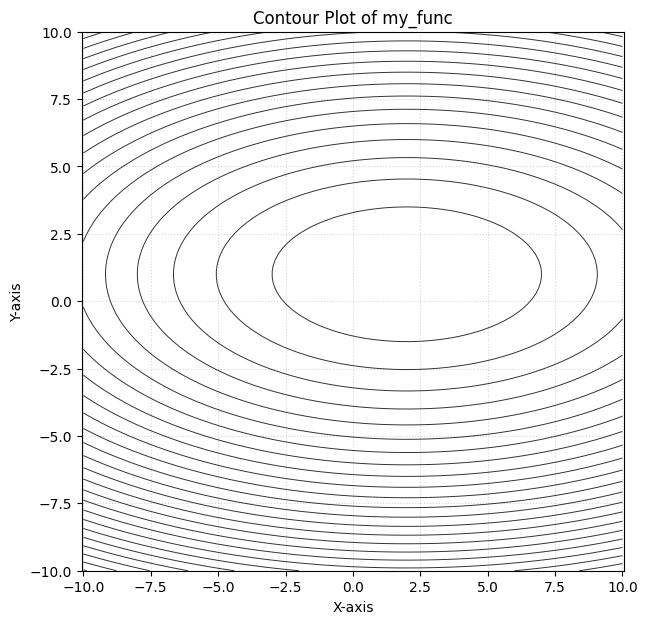

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def plot_contours(func, func_name="2D Function", x_range=(-5, 5), y_range=(-5, 5), resolution=100, num_levels=15):

    x = np.linspace(x_range[0], x_range[1], resolution)
    y = np.linspace(y_range[0], y_range[1], resolution)
    X, Y = np.meshgrid(x, y)

    Z = func(X, Y)

    plt.figure(figsize=(7, 7))

    plt.contourf(X, Y, Z, levels=num_levels, colors='white')
    #plt.colorbar(label='Function Value Z')

    contours = plt.contour(X, Y, Z, levels=num_levels, colors='black', linewidths=0.7, alpha=0.8)

    #plt.clabel(contours, inline=True, fontsize=9, fmt='%1.1f')

    plt.title(f'Contour Plot of {func_name}')
    plt.xlabel('X-axis')
    plt.ylabel('Y-axis')
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.axis('equal')
    plt.show()

# -----------------------------------------------------------------
# Define your 2D function here:
# -----------------------------------------------------------------

def my_func(x, y):
    # Example objective function
    return ( (x-2)**2 + 4*(y-1)**2 )

# -----------------------------------------------------------------
# Call the plotting function:
# -----------------------------------------------------------------

plot_contours(
    func=my_func,
    func_name="my_func",
    x_range=(-10, 10),
    y_range=(-10, 10),
    num_levels=25
)

**b.** Determine the gradient $f^\prime$.  Remember that this should be a vector whose entries may depend on $w_1$ and $w_2$.  Which gradient do you find when both paramters are set to zero?

**c.** Make three different plots, one for every learning rate $0.1$, $0.01$, and $0.001$, in which you initialize $w$ at time $0$ with $(0,0)^T$ and where you plot he value of $w_t$ for the first 10 gradient steps in a contour plot of the objective function (see previous item b.).

**d.**  What solution does gradient descent find after 10,000 iterations with the three different larning rates from c?

**e.** What happens to the solution you find when you set the learning rate to something large, e.g., when you take $a = 100$?

# **Part B**

# **Exercise $\infty$ - 1**

Consider a 2-class classification problem where the first class is only distributed in the first and third quadrant, while the second class is only located in the second and fourth quadrant.  If there is indeed data in all four quadrants, we typically cannot find a linear classifier that seprates the two classes perfectly.

Nevertheless, a simple transformation of the two original features (refer to them with x and y?) can lead to the classes being linearly separable.  What is the simplest transformation you can think of that achieves such separability?

# **Exercise $\infty$**

Consider a two-class classification problem in 2D.  The first class is distributed uniformly between the two concentric circles around the origin with radius 1 and 2, respectively.  The second class is distributed uniformly between the two concentric circles around the origin with radius 3 and $\pi$, respectively.

**a.** Explain whether or not the two classes are linearly seprable.

**b.** Constuct a third feature that equals the distance to the origin, i.e., call the original features $a_1$ and $a_2$, then the new feature equals $\sqrt{a_1^2 + a_2^2}$.

In this 3D attribute space, are the two classes linearly seperable?  (No need to mention, of course, that you should always explain your answer...)

**c.** Do we need all three feature from b. for the two classes to be linearly seprable?

**d.** Now, take three alternative features, which all derive from the first feature value $a_1$: $a_1$ itself, $\sin(a_1)$, and $\cos(a_1)$.  Explain why the two classes cannot be perfectly separated in this 3D feature space.  

(Hint? : no feature transformation that is merely based on $a_1$ can provide a data representation in which the two classes are perfectly separable.)

## **Exercise $\infty$ + 1** - Overfitting for Decision Trees...

We use Decision Trees to illustrate how there is such a thing as a model that fits your data too well!

To start with, we generate a random dataset with two continuous interval variables, which we call 'X0' and 'X1'.  The dataset has class labels 'Class 0' and 'Class 1'.

In [4]:
import numpy as np
random_state = 1
n = 100
X = np.concatenate((np.random.rand(n,2)-0.5,np.random.rand(n,2)*2-1),0)
y = np.concatenate((np.repeat(0,n),np.repeat(1,n)))

**a.** Firstly, let's inspect the data. Make a scatterplot in which X0 is on the x-axis, X1 is on the y-axis, and the color of the data points is which class they belong to. Choose blue for Class 0, and red for Class 1.

In [5]:
import matplotlib.pyplot as plt

# YOUR CODE HERE
raise NotImplementedError()

NotImplementedError: 

**b.** The two classes appear to have a clearly different distribution. However, some data points are harder to classify than others. Which specific data points do you think will be the hardest for a decision tree to classify in terms of accuracy? Specify the Class, levels of X0, and levels of X1.

We now make two decision trees. Throughout the exercise, we will compare the performance of these trees to each other.

**c.** Make one simple tree, with a low depth (set min_samples_split to 100, and max_depth to 4) and one complex tree, with a high depth (set min_samples_split to 2, and max_depth to 100).

Show what both trees look like

In [ ]:
from sklearn import tree
import matplotlib.pyplot as plt

SimpleTree = None
ComplexTree = None

# YOUR CODE HERE
raise NotImplementedError()

Now, let's look at how the decision tree makes its decisions.  We can visualize this, because there are only two attributes.  Run the code below to plot the training data points and those decision boundaries for your decision trees.

In [ ]:
# Plot the decision boundary
from sklearn.inspection import DecisionBoundaryDisplay
#ax = plt.gca()
ax = plt.subplot(1,2,1)
ax.set_xlim([-1, 1])
ax.set_ylim([-1,1])
DecisionBoundaryDisplay.from_estimator(
    SimpleTree,
    X,
    cmap=plt.cm.RdYlBu,
    ax = ax,
    response_method="predict",
    xlabel='X0',
    ylabel='X1',
)
plt.scatter(
    X[y==0, 0],
    X[y==0, 1],
    c='red',
    label='Class 0',
    edgecolor="black",
    #s=15,
)
plt.scatter(
    X[y==1, 0],
    X[y==1, 1],
    c='blue',
    label='Class 1',
    edgecolor="black",
    #s=15,
)
plt.legend()
plt.title('Simple Tree')

ax = plt.subplot(1,2,2)
ax.set_xlim([-1, 1])
ax.set_ylim([-1,1])
DecisionBoundaryDisplay.from_estimator(
    ComplexTree,
    X,
    cmap=plt.cm.RdYlBu,
    ax = ax,
    response_method="predict",
    xlabel='X0',
    ylabel='X1',
)
plt.scatter(
    X[y==0, 0],
    X[y==0, 1],
    c='red',
    label='Class 0',
    edgecolor="black",
    #s=15,
)
plt.scatter(
    X[y==1, 0],
    X[y==1, 1],
    c='blue',
    label='Class 1',
    edgecolor="black",
    #s=15,
)
plt.legend()
plt.title('Complex Tree')


plt.show()

**d.** These plots show which areas are assigned to what class.

Which decision tree do you think has a higher accuracy on the training dataset?  And why?

Now, let's generate some more data, to observe how well our trained decision trees will perform on new data!

In [ ]:
import matplotlib.pyplot as plt
random_state=1
Xnew = np.concatenate((np.random.rand(n,2)-0.5,np.random.rand(n,2)*2-1),0)
ynew = np.concatenate((np.repeat(0,n),np.repeat(1,n)))

ax = plt.subplot(1,2,1)
ax.set_xlim([-1, 1])
ax.set_ylim([-1,1])
DecisionBoundaryDisplay.from_estimator(
    SimpleTree,
    X,
    cmap=plt.cm.RdYlBu,
    ax = ax,
    response_method="predict",
    xlabel='X1',
    ylabel='X2',
)
plt.scatter(
    Xnew[ynew==0, 0],
    Xnew[ynew==0, 1],
    c='red',
    label='Class 0',
    edgecolor="black",
    #s=15,
)
plt.scatter(
    Xnew[ynew==1, 0],
    Xnew[ynew==1, 1],
    c='blue',
    label='Class 1',
    edgecolor="black",
    #s=15,
)
plt.legend()
plt.title('Simple Tree')

ax = plt.subplot(1,2,2)
ax.set_xlim([-1, 1])
ax.set_ylim([-1,1])
DecisionBoundaryDisplay.from_estimator(
    ComplexTree,
    X,
    cmap=plt.cm.RdYlBu,
    ax = ax,
    response_method="predict",
    xlabel='X1',
    ylabel='X2',
)
plt.scatter(
    Xnew[ynew==0, 0],
    Xnew[ynew==0, 1],
    c='red',
    label='Class 0',
    edgecolor="black",
    #s=15,
)
plt.scatter(
    Xnew[ynew==1, 0],
    Xnew[ynew==1, 1],
    c='blue',
    label='Class 1',
    edgecolor="black",
    #s=15,
)
plt.legend()
plt.title('Complex Tree')


plt.show()

**e.** Compute the accuracy of both trees on the new data (Xnew and ynew).

In [ ]:
Accuracy_SimpleTree =  None
Accuracy_ComplexTree = None
# YOUR CODE HERE
raise NotImplementedError()
print((Accuracy_SimpleTree, Accuracy_ComplexTree))

**f.** Based on the accuracies and the plots above, which decision tree should you use to classify new data?  If the answer is different from the last question, why did it change?

# **Exercise $\infty$ + 2** - Pruning...

Now that we know that overfitting can be dangerous and lower model performance, we want to avoid it. It turns out that we can use cross-validation to select how complex we want our tree to become.

When applying cross-validation the observed data is split into training and test sets, e.g., ```X_train```, ```y_train```, ```X_test```, and ```y_test```. We train the model on the training data and evaluate the performance of the trained model on the test data.

**A.**

We are using the wine dataset ```data/wine.mat``` that we already used for Assignment 6.

Divide the data into a training and a test data set by applying holdout cross-validation (see hints below). Use a stratified split, and set the percentage of testing data to 33%.

We want to find an optimally pruned decision tree by modifying its maximum depth. (We leave the ```min_samples_split``` variable at its default value.)  Now, for different values of the parameter depth (say, from 2 up to and incuding 20)
- create the decision tree object;
- fit the decision tree;
- predict the labels of the train and test data separately (name them ```y_test_pred``` and ```y_train_pred```);
- then compute the classification error on the training and test set.

Plot the training and test classification error, in the same figure, as a function of the tree depth. Add a legend to the plot! This will show us what the optimal pruning depth is for the training set, but also how well this generalizes to a test set.

What appears to be the optimal tree depth? Do you get the same result when you run your code again, generating a new random split between training and test data?

What happens to the test and train error when you set the ```min_samples_split``` parameter to 100?

####
> (Helpful) hints: Take a look at the module ```sklearn.model_selection``` and see how it can be used to partition the data into a training and a test set (holdout validation, ```train_test_split()``` function). Note that the package also contains functions to partition data for K-fold cross-validation. Some of the functions can ensure that both training and test sets have roughly the same class proportions. Read the documentation, and make sure you have a stratified split! The error is calculated as  $1−accuracy$. The easiest way to compute the accuracy is by using the sklearn metrics module: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html

In [ ]:
from sklearn import model_selection, tree
import numpy as np
from scipy.io import loadmat

random_state = 1337

wine_data = loadmat('data/wine.mat')

X = np.array(wine_data['X'])
y = np.array(wine_data['y'])

X_train, X_test, y_train, y_test = None, None, None, None

# YOUR CODE HERE
raise NotImplementedError()

**B.**

Repeat the exercise above, using stratified 10-fold cross-validation. K-fold cross-validation works by splitting X into K partitions of equal length. Then in each fold, you choose K-1 partitions as the training set and the remaining partition as the test set. Every partition gets a turn being a test set. For a very nice simple explanation of how (and why) K-fold works, check out http://www.dummies.com/programming/big-data/data-science/resorting-cross-validation-machine-learning/

You will need a double for loop for this exercise. Think about what the best order of the loops is.

For each fold, fit a decision tree on the training set and evaluate its performance on the test set. Finally, compute the average classification errors on the test- and training sets across the 10 cross-validation folds and plot them as a function of the tree depth.

What appears to be the optimal tree depth? Do you get the same result when you run your code again, generating a new random split between training and test data? How about 100-fold cross-validation?

####
> Some hints: This time the ```StratifiedKFold()``` function from the module ```sklearn.model_selection``` can be used to partition the data into the 10 training and test partitions. Check out http://scikit-learn.org/stable/modules/cross_validation.html#k-fold for an example of how to acces the indices for the training set and the test set in each fold. Those indices can then be used to create the training and test set, e.g. ```X_train = X[train_indices]``` If you are creating a for loop iterating over an object where you both need the index and the elements of the object, you can enumerate the object. For example: ```for index, (element) in enumerate(object): array[index] = operation(element)```

In [ ]:
# YOUR CODE HERE
raise NotImplementedError()

# **Exercise $\infty$ + 3** - Reflections on Data and Dimension

**a.** For 1-dimensional regression, does more training data lead to more computations to train the regression function?

**b.** For 1-dimensional regression, does more training data typically lead to better predictions on new and unseen data?  Does more training data typically lead to a better fit on eactly this training data?

**c.** In classification, the more features you measure on the objects, the more you know about these objects, and so the better the classifier you train should be on new and unseen data.  Or should it?

**d.** In regression, assuming a single input attribute $x$, one can extend the input vector with higher-degree polynomial transformations of this single input (i.e., $x^2$, $x^3$, $x^4$, etc.).  Why will the training error typically decrease while the degree increases?  Will the test error typically show the same behavior?

